Training GradientBoosting...
Training SARIMAX (Rolling Forecast)...


c:\Users\62812\miniconda3\envs\data-science\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\62812\miniconda3\envs\data-science\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\62812\miniconda3\envs\data-science\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\62812\miniconda3\envs\data-science\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\62812\miniconda


--- HASIL FINAL ---
MAPE GradientBoosting: 2.12%
MAPE SARIMAX Rolling: 1.64%


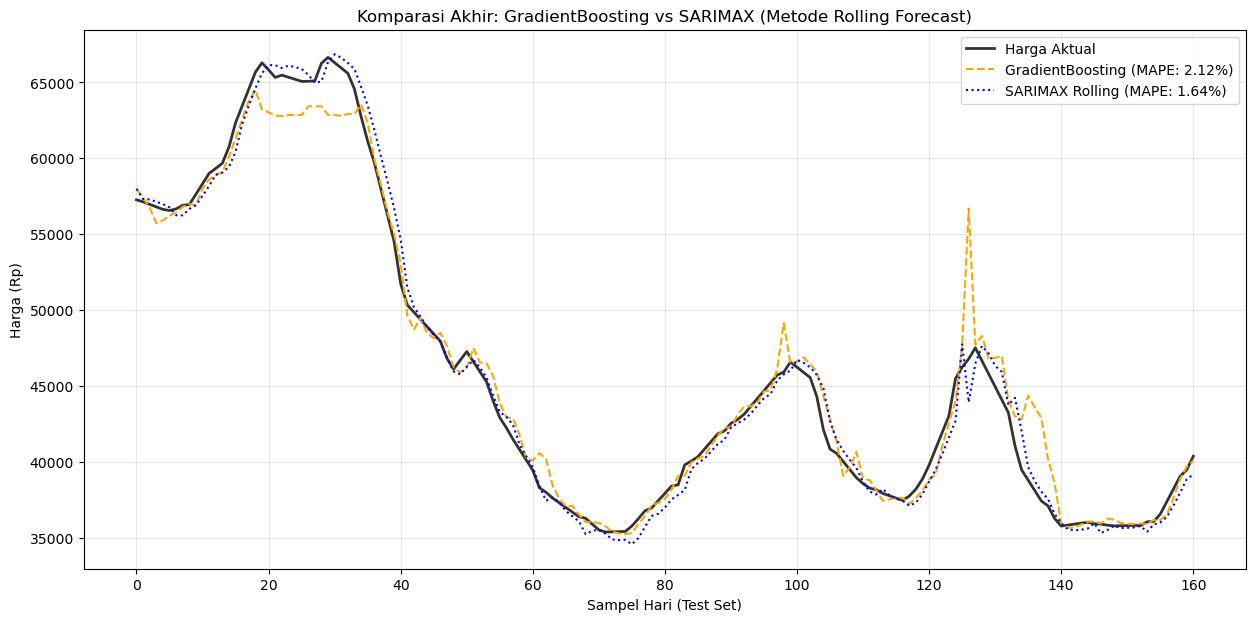

2026/05/03 21:37:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 21:38:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/05/03 21:38:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 21:38:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error as mape
import mlflow
import mlflow.sklearn
import mlflow.statsmodels
import dagshub

dagshub.init(repo_owner='DEKHSA_AFNAN', repo_name='NAMA_REPO', mlflow=True)

# Start MLflow run
with mlflow.start_run():
    # Log experiment description
    mlflow.log_param("experiment_description", "Comparison of GradientBoosting and SARIMAX Rolling Forecast for Time Series Prediction")
    
    # 2. PREPARASI DATA (Label Encoding & Integer Casting)
    df = pd.read_csv('../../data/processed/data_with_holidays.csv')
    df['tanggal_data'] = pd.to_datetime(df['tanggal_data'])
    df = df.sort_values('tanggal_data')

    # Label Encoding 'jenis_libur'
    df['jenis_libur'] = df['jenis_libur'].fillna('Bukan Libur')
    le = LabelEncoder()
    df['jenis_libur_encoded'] = le.fit_transform(df['jenis_libur'])

    # Ubah 'is_libur' ke integer (0/1)
    df['is_libur'] = df['is_libur'].astype(int)

    # Handling Gap Tanggal & Interpolasi
    df = df.set_index('tanggal_data').reindex(pd.date_range(df['tanggal_data'].min(), df['tanggal_data'].max(), freq='D'))
    df['harga'] = df['harga'].interpolate(method='linear')
    df['is_libur'] = df['is_libur'].fillna(0).astype(int)
    df['jenis_libur_encoded'] = df['jenis_libur_encoded'].fillna(le.transform(['Bukan Libur'])[0]).astype(int)

    # 3. PEMBUATAN DATASET WINDOW (XGBOOST)
    def create_window_dataset(data, window_size, horizon):
        X, y = [], []
        prices = data['harga'].values
        libur_bin = data['is_libur'].values
        libur_type = data['jenis_libur_encoded'].values
        for i in range(len(data) - window_size - horizon + 1):
            window_prices = prices[i : i + window_size]
            target_holiday_bin = libur_bin[i + window_size + horizon - 1]
            target_holiday_type = libur_type[i + window_size + horizon - 1]
            features = np.append(window_prices, [target_holiday_bin, target_holiday_type])
            X.append(features)
            y.append(prices[i + window_size + horizon - 1])
        return np.array(X), np.array(y)

    WINDOW = 7
    HORIZON = 1
    X, y = create_window_dataset(df, WINDOW, HORIZON)

    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Log dataset parameters
    mlflow.log_param("window_size", WINDOW)
    mlflow.log_param("horizon", HORIZON)
    mlflow.log_param("train_split_ratio", 0.8)
    mlflow.log_param("total_samples", len(X))
    mlflow.log_param("train_samples", len(X_train))
    mlflow.log_param("test_samples", len(X_test))

    # 4. MODEL 1: GRADIENT BOOSTING (replacing XGBoost)
    print("Training GradientBoosting...")
    model_gb = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
    model_gb.fit(X_train, y_train)
    pred_gb = model_gb.predict(X_test)

    # Log GradientBoosting parameters
    mlflow.log_param("gb_n_estimators", 500)
    mlflow.log_param("gb_learning_rate", 0.05)
    mlflow.log_param("gb_max_depth", 6)
    mlflow.log_param("gb_random_state", 42)

    # 5. MODEL 2: SARIMAX (ROLLING FORECAST - ONE STEP AHEAD)
    print("Training SARIMAX (Rolling Forecast)...")
    train_df = df.iloc[:split + WINDOW]
    test_df = df.iloc[split + WINDOW :]

    history_price = list(train_df['harga'])
    history_exog = train_df[['is_libur', 'jenis_libur_encoded']].values.tolist()
    pred_sarima_rolling = []

    # Log SARIMAX parameters
    mlflow.log_param("sarimax_order", "(1, 1, 1)")
    mlflow.log_param("sarimax_seasonal_order", "(1, 1, 1, 7)")
    mlflow.log_param("sarimax_enforce_stationarity", False)
    mlflow.log_param("sarimax_enforce_invertibility", False)
    mlflow.log_param("sarimax_maxiter", 200)
    mlflow.log_param("sarimax_method", "nm")

    # Proses rolling: model di-update setiap kali ada data baru di test set
    for i in range(len(test_df)):
        try:
            model_s = SARIMAX(history_price, 
                              exog=history_exog, 
                              order=(1, 1, 1), 
                              seasonal_order=(1, 1, 1, 7),
                              enforce_stationarity=False, # Menambah stabilitas
                              enforce_invertibility=False)
            
            # Gunakan maxiter lebih tinggi dan filter warnings
            model_s_fit = model_s.fit(disp=False, maxiter=200, method='nm') 
            
            curr_exog = [test_df[['is_libur', 'jenis_libur_encoded']].iloc[i].values]
            out = model_s_fit.forecast(steps=1, exog=curr_exog)
            pred_sarima_rolling.append(out[0])
            
        except:
            # Jika benar-benar gagal konvergen, gunakan nilai sebelumnya (naive) agar skrip tidak berhenti
            pred_sarima_rolling.append(history_price[-1])
            
        history_price.append(test_df['harga'].iloc[i])
        history_exog.append(test_df[['is_libur', 'jenis_libur_encoded']].iloc[i].values.tolist())

    # 6. EVALUASI & VISUALISASI
    mape_gb = mape(y_test, pred_gb) * 100
    mape_sarima = mape(y_test, pred_sarima_rolling) * 100

    # Log metrics
    mlflow.log_metric("MAPE_GradientBoosting", mape_gb)
    mlflow.log_metric("MAPE_SARIMAX", mape_sarima)

    print(f"\n--- HASIL FINAL ---")
    print(f"MAPE GradientBoosting: {mape_gb:.2f}%")
    print(f"MAPE SARIMAX Rolling: {mape_sarima:.2f}%")

    # Create and save plot
    plt.figure(figsize=(15, 7))
    plt.plot(y_test, label='Harga Aktual', color='black', alpha=0.8, linewidth=2)
    plt.plot(pred_gb, label=f'GradientBoosting (MAPE: {mape_gb:.2f}%)', color='orange', linestyle='--')
    plt.plot(pred_sarima_rolling, label=f'SARIMAX Rolling (MAPE: {mape_sarima:.2f}%)', color='blue', linestyle=':')
    plt.title('Komparasi Akhir: GradientBoosting vs SARIMAX (Metode Rolling Forecast)')
    plt.xlabel('Sampel Hari (Test Set)')
    plt.ylabel('Harga (Rp)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Save plot and log as artifact
    plot_path = "comparison_plot.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path)
    plt.show()

    # Log models
    mlflow.sklearn.log_model(model_gb, "gradientboosting_model")
    # For SARIMAX, log the last fitted model
    mlflow.statsmodels.log_model(model_s_fit, "sarimax_model")